# **CAPE** Shiller Ratio Reconstruction

Source: https://shillerdata.com/

In [ ]:
# !pip install wrds
# !pip install fredapi

In [ ]:
import os
import pandas as pd
from datetime import datetime
import getpass
from wrds import Connection
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

In [ ]:
db = Connection()

Enter your WRDS username [root]:robinglee
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [ ]:
# Date range
start_year = 2000
end_year = 2024
# Set to False to match WRDS signals_raw_plus
CPI_ADJUSTED = False
# fred api key (optional)
fred_api=''

In [ ]:
# retrieve cpi data from Fred
fred = Fred(api_key='b2a58003f065b0e11ceed90bdd77e069')
cpi = fred.get_series('CPIAUCSL', observation_start='1960-01-01')
cpi_df = cpi.to_frame(name='cpi').reset_index()
cpi_df.columns = ['month_date', 'cpi']
cpi_df['month_date'] = cpi_df['month_date'] + pd.offsets.MonthEnd(0)

current_cpi = cpi_df['cpi'].iloc[-1]
cpi_df['real_multiplier'] = current_cpi / cpi_df['cpi']
cpi_df = cpi_df.set_index('month_date')

## Manual Shiller Ratio Reconstruction

Shiller's earnings series is the S&P index-level earnings as officially reported by S&P Dow Jones Indices (not a bottom-up aggregation by using `funda` or `msf`). It incorporates S&P's own methodology for handling:

* Earnings restatements
* Constituent changes
* As-reported vs. operating earnings (Shiller uses as-reported)
* Interpolation between quarterly releases

**Replicating using WRDS data and the bottom-up strategy:**

Replicate Shiller's CAPE ratio using only WRDS data. CAPE = real S&P 500 price divided by the 10-year rolling average of real S&P 500 earnings. The challenge is that WRDS has no pre-computed index-level earnings series, so we have to build it bottom-up from individual firm financials.

Pull every stock that was ever in the S&P 500, with the exact dates it entered and left the index (remove survivorship and inclusion bias). Need to use permno (permanent identifier)

In [ ]:
# every S&P 500 permno with its inclusion/exclusion date
constituents = db.raw_sql("""
    SELECT permno,
           start  AS start_date,
           ending AS end_date
    FROM crsp.dsp500list
    ORDER BY permno, start
""")
constituents['start_date'] = pd.to_datetime(constituents['start_date'])
constituents['end_date']   = pd.to_datetime(constituents['end_date'])

In [ ]:
constituents.head()

,permno,start_date,end_date
0,10006,1957-03-01,1984-07-18
1,10030,1957-03-01,1969-01-08
2,10049,1925-12-31,1932-10-01
3,10057,1957-03-01,1992-07-02
4,10078,1992-08-20,2010-01-28


Link price data with earnings data

* firm's permno -> gvkey mapping can change over time due to mergers and spin-offs, so `linkdt` and `linkenddt` must be respected when joining.

In [ ]:
# CRSP/Compustat Merged (CCM) link table (link concept/unqualified + primary/conditional links)
ccm_link = db.raw_sql("""
    SELECT lpermno  AS permno,
           gvkey,
           linkdt,
           linkenddt
    FROM crsp.ccmxpf_lnkhist
    WHERE linktype IN ('LC', 'LU')
      AND linkprim IN ('P', 'C')
""")
ccm_link['linkdt']    = pd.to_datetime(ccm_link['linkdt'])
ccm_link['linkenddt'] = pd.to_datetime(ccm_link['linkenddt'].fillna('2099-12-31'))

Quarterly Earnings from Compustat:
* `ibq`: income before extraordinary items, quarterly. This is Shiller's "as-reported" earnings definition
* `cshoq`: common shares outstanding at quarter end (in millions)
* `ajexq`: cumulative adjustment factor for stock splits. Needed to make shares comparable over time
* `prccq`: quarter-end stock price from Compustat, used to compute market cap for value-weighting

In [ ]:
# quarterly earnings
# ibq  = income before extraordinary items (as-reported, matches Shiller)
# cshoq * ajexq = split-adjusted shares outstanding (for per-share calc)
#  sum 4 trailing quarters (TTM EPS), then aggregate to index level
earnings_raw = db.raw_sql(f"""
    SELECT f.gvkey,
           f.datadate,
           f.ibq, -- millions of dollars
           f.cshoq, -- millions
           f.ajexq,
           f.prccq
    FROM comp.fundq f
    WHERE f.indfmt  = 'INDL' --industrial format only
      AND f.datafmt = 'STD' --standardised format
      AND f.popsrc  = 'D' --domestic firms only
      AND f.consol  = 'C' --consolidated statements only
      AND f.datadate >= '{start_year - 11}-01-01'
      AND f.datadate <= '{end_year}-12-31'
      AND f.ibq   IS NOT NULL
      AND f.cshoq IS NOT NULL
""")
earnings_raw['datadate'] = pd.to_datetime(earnings_raw['datadate'])

In [ ]:
earnings_raw.head()

,gvkey,datadate,ibq,cshoq,ajexq,prccq
0,001003,1989-01-31,-5.419,2.683,1.0,1.75
1,001003,1989-07-31,0.415,2.683,1.0,0.75
2,001003,1990-01-31,-1.603,2.683,1.0,0.125
3,001003,1990-04-30,-0.828,2.683,1.0,<NA>
4,001003,1990-07-31,-1.322,2.683,1.0,0.094


S&P 500 price index level (numerator of the CAPE ratio)
* monthly average of daily closes
* no earnings columns, so need the bottom-up pipeline above

In [ ]:
# S&P price index
price = db.raw_sql(f"""
    SELECT caldt, spindx AS price
    FROM crsp.msp500
    WHERE caldt >= '{start_year - 11}-01-01'
      AND caldt <= '{end_year}-12-31'
    ORDER BY caldt
""")
price['date'] = pd.to_datetime(price['caldt']) + pd.offsets.MonthEnd(0)
price = price.set_index('date')[['price']]

In [ ]:
price.tail()

,price
date,
2024-08-31,5648.4
2024-09-30,5762.48
2024-10-31,5705.45
2024-11-30,6032.38
2024-12-31,5881.63


For every quarterly earnings observation, make sure the gvkey/permno link is valid on the date and the permno belongs in the S&P 500 at that date:

In [ ]:
# merge S&P constituents to ccm link and then to earnings
eq = earnings_raw.merge(ccm_link, on='gvkey', how='inner')
eq = eq[
    (eq['datadate'] >= eq['linkdt']) &
    (eq['datadate'] <= eq['linkenddt'])
]

eq = eq.merge(constituents, on='permno', how='inner')
eq = eq[
    (eq['datadate'] >= eq['start_date']) &
    (eq['datadate'] <= eq['end_date'])
]

eq = eq[['gvkey', 'permno', 'datadate', 'ibq', 'cshoq', 'ajexq', 'prccq']].copy()
eq = eq.sort_values(['gvkey', 'datadate'])

In [ ]:
eq.head()

,gvkey,permno,datadate,ibq,cshoq,ajexq,prccq
43,001013,50906.0,1999-10-31,41.1,150.173,0.571428,47.6875
44,001013,50906.0,2000-01-31,53.1,151.686,0.571428,65.9375
45,001013,50906.0,2000-04-30,718.2,306.685,0.285714,60.75
46,001013,50906.0,2000-07-31,9.7,709.025,0.142857,41.9375
47,001013,50906.0,2000-10-31,87.1,770.3,0.142857,21.375


Sum each firm's 4 most recent quarterly earnings to get trailing twelve months (TTM) earnings:

In [ ]:
# firm-level ttm eps
# sum ibq over the trailing 4 quarters for each firm (requires all 4)
eq['ttm_earnings'] = (
    eq.groupby('gvkey')['ibq']
    .transform(lambda x: x.rolling(4, min_periods=4).sum()) # prevent understatement
)

eq = eq.dropna(subset=['ttm_earnings', 'cshoq', 'prccq'])

# Market cap weight (common shares outstanding at quarter end * quarter-end stock price)
eq['mktcap'] = eq['cshoq'] * eq['prccq']

 Collapse from firm-level quarterly observations to a single index-level earnings figure per month:

 * Compustat reports quarterly but CAPE needs monthly observations. Each quarterly earnings figure is valid for 3 months until the next quarter is reported, so we expand each row into 3 monthly observations. Without this step, only ~160 firms contribute in any given month (those whose fiscal quarter literally ended that month) instead of the full ~480.

In [ ]:
eq['datadate'] = pd.to_datetime(eq['datadate'])

eq_list = []
for offset in range(3):
    tmp = eq.copy()
    tmp['month'] = tmp['datadate'] + pd.offsets.MonthEnd(offset)
    eq_list.append(tmp)

eq_monthly = pd.concat(eq_list, ignore_index=True)

eq_monthly = eq_monthly.sort_values(['gvkey', 'month', 'datadate'])

# if a firm has two quarterly observations falling in the same month, keep the most recent
eq_monthly = eq_monthly.drop_duplicates(subset=['gvkey', 'month'], keep='last')

Collapse firm-level quarterly data into a single index-level earnings figure per month
* S&P 500 is market-cap weighted, so need to divide total earnings by total market cap to get value-weighted earnings yield

In [ ]:
# aggregate to index-level monthly earnings (shiller uses total index earnings)

eq['month'] = eq['datadate'] + pd.offsets.MonthEnd(0)

# For each month, aggregate across all S&P 500 members
monthly = (
    eq_monthly.groupby('month')
    .apply(lambda g: pd.Series({
        'total_ttm_earnings': g['ttm_earnings'].sum(),
        'total_mktcap':       g['mktcap'].sum(),
        'n_firms':            g['gvkey'].nunique()
    }))
    .reset_index()
    .rename(columns={'month': 'date'})
)

monthly['date'] = pd.to_datetime(monthly['date'])
monthly = monthly.set_index('date').sort_index()
monthly['earnings_yield'] = monthly['total_ttm_earnings'] / monthly['total_mktcap']

In [ ]:
monthly.tail()

,total_ttm_earnings,total_mktcap,n_firms,earnings_yield
date,,,,
2024-10-31,1801836.552,5.090869e+07,486.0,0.035393
2024-11-30,1805900.379,5.107715e+07,486.0,0.035356
2024-12-31,1881359.232,5.151477e+07,485.0,0.036521
2025-01-31,1693083.072,4.409226e+07,448.0,0.038399
2025-02-28,1636738.832,4.191361e+07,426.0,0.039050


Compute CAPE:
* Real price divided by 10-year average real earnings

In [ ]:
df = price.join(monthly[['earnings_yield', 'n_firms']], how='inner')
df = df.join(cpi_df[['cpi', 'real_multiplier']], how='inner')

# earnings in price terms
df['earnings_level'] = df['earnings_yield'] * df['price']

# forward-fill quarterly earnings to monthly
df['earnings_level'] = df['earnings_level'].ffill()

# deflate to current dollars
df['real_price']    = df['price'] * df['real_multiplier']
df['real_earnings'] = df['earnings_level'] * df['real_multiplier']

# 10-year (120-month) rolling mean of real earnings
df['avg_real_earnings_10y'] = df['real_earnings'].rolling(120, min_periods=120).mean()

# CAPE
df['CAPE'] = df['real_price'] / df['avg_real_earnings_10y']

result_manual_wrds = df[['price', 'real_price', 'real_earnings', 'avg_real_earnings_10y', 'CAPE', 'n_firms']].dropna()

In [ ]:
result_manual_wrds

,price,real_price,real_earnings,avg_real_earnings_10y,CAPE,n_firms
1999-09-30,1282.71,2496.529759,89.533274,65.568667,38.075042,464.0
1999-10-31,1362.93,2647.927322,94.793252,65.908009,40.176108,465.0
1999-11-30,1388.91,2693.59465,95.970989,66.260824,40.651391,467.0
1999-12-31,1469.25,2842.650586,99.199524,66.576721,42.697366,463.0
2000-01-31,1394.46,2689.981704,92.825993,66.878748,40.221771,462.0
...,...,...,...,...,...,...
2024-08-31,5648.4,5873.679908,215.072367,169.263815,34.701332,485.0
2024-09-30,5762.48,5979.553456,212.750542,169.790196,35.217307,486.0
2024-10-31,5705.45,5903.512344,208.945961,170.261274,34.673254,486.0
2024-11-30,6032.38,6224.103142,220.061414,170.795182,36.441913,486.0


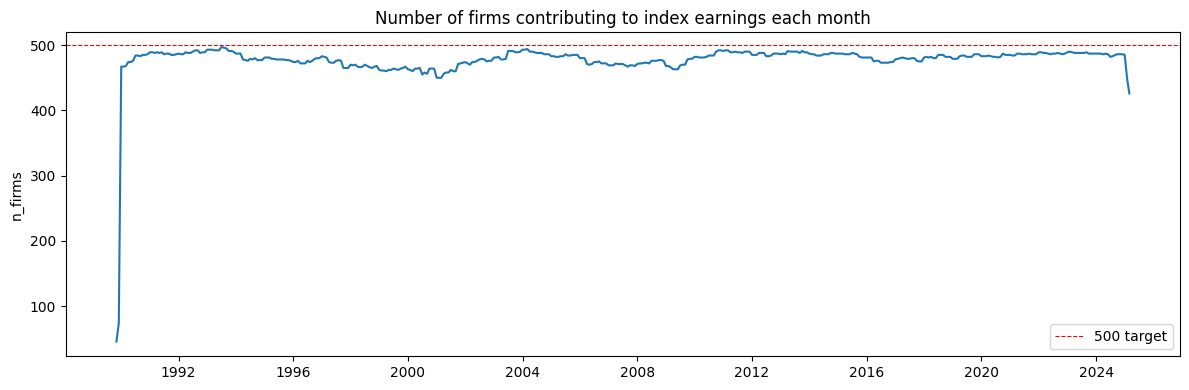

date
1980    195.7
1990    478.5
2000    474.4
2010    484.0
2020    484.5
Name: n_firms, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['n_firms'])
ax.axhline(500, color='red', linestyle='--', linewidth=0.8, label='500 target')
ax.set_title('Number of firms contributing to index earnings each month')
ax.set_ylabel('n_firms')
ax.legend()
plt.tight_layout()
plt.show()


# Average coverage by decade
print(monthly.groupby(
    monthly.index.year // 10 * 10
)['n_firms'].mean().round(1))

## Shiller Online Data

In [ ]:
df = pd.read_excel(
    'http://www.econ.yale.edu/~shiller/data/ie_data.xls',
    sheet_name='Data',
    header=7,
    skipfooter=2
)

In [ ]:
df2 = df.iloc[:, [0, 7, 10, 12]].copy()
df2.columns = ['date_raw', 'real_price', 'real_earnings', 'cape_shiller']

In [ ]:
def parse_shiller_date(d):
    s = str(d)
    year, month = s.split('.')
    month = month.ljust(2, '0')
    return pd.to_datetime(f'{year}-{month}') + pd.offsets.MonthEnd(0)

In [ ]:
df3 = df2.dropna(subset=['date_raw', 'real_price', 'real_earnings'])
df3['date'] = df3['date_raw'].apply(parse_shiller_date)
df3 = df3.set_index('date').sort_index()

In [ ]:
df3.head()

,date_raw,real_price,real_earnings,cape_shiller
date,,,,
1871-01-31,1871.01,109.050018,9.824326,NaN
1871-02-28,1871.02,107.248908,9.533236,NaN
1871-03-31,1871.03,108.266269,9.394036,NaN
1871-04-30,1871.04,115.536124,9.749884,NaN
1871-05-31,1871.05,121.215781,9.976607,NaN


In [ ]:
df3['avg_real_earnings_10y'] = (
    df3['real_earnings']
    .rolling(window=120, min_periods=120)
    .mean()
)

In [ ]:
df3['CAPE'] = df3['real_price'] / df3['avg_real_earnings_10y']

In [ ]:
result_shiller = df3[['real_price', 'real_earnings',
             'avg_real_earnings_10y', 'CAPE', 'cape_shiller']].dropna()

In [ ]:
result_shiller['diff'] = result_shiller['CAPE'] - result_shiller['cape_shiller']
result_shiller['abs_diff'] = result_shiller['diff'].abs()

# print(result_shiller.tail(12).round(2))
print(f"\nMean absolute difference vs Shiller: {result_shiller['abs_diff'].mean():.4f}")
print(f"Max absolute difference vs Shiller:  {result_shiller['abs_diff'].max():.4f}")

print("\nLargest deviations:")
print(result_shiller[['CAPE', 'cape_shiller', 'diff', 'abs_diff']].nlargest(10, 'abs_diff').round(4))


Mean absolute difference vs Shiller: 0.0503
Max absolute difference vs Shiller:  0.3253

Largest deviations:
               CAPE  cape_shiller    diff  abs_diff
date                                               
2019-04-30  29.8082       30.1335 -0.3253    0.3253
2019-03-31  29.2517       29.5762 -0.3245    0.3245
2019-02-28  29.2220       29.5415 -0.3195    0.3195
2019-05-31  28.9303       29.2420 -0.3118    0.3118
2019-06-30  28.9747       29.2838 -0.3091    0.3091
2019-07-31  29.6809       29.9867 -0.3058    0.3058
2019-01-31  28.0784       28.3802 -0.3018    0.3018
2018-12-31  27.9972       28.2919 -0.2947    0.2947
2019-08-31  28.4220       28.7054 -0.2834    0.2834
2018-11-30  29.9143       30.1956 -0.2813    0.2813


## Comparison

In [ ]:
wrds_cape = result_manual_wrds[['CAPE']].rename(columns={'CAPE': 'CAPE_wrds'})
shiller_cape = result_shiller[['CAPE', 'cape_shiller']].rename(columns={'CAPE': 'CAPE_shiller_replicated'})

In [ ]:
comparison = wrds_cape.join(shiller_cape, how='inner')

In [ ]:
comparison['diff_vs_replicated'] = comparison['CAPE_wrds'] - comparison['CAPE_shiller_replicated']
comparison['diff_vs_published']  = comparison['CAPE_wrds'] - comparison['cape_shiller']
comparison['abs_diff_published'] = comparison['diff_vs_published'].abs()
comparison['abs_diff_replicated'] = comparison['diff_vs_replicated'].abs()
print("Largest divergences (WRDS vs published):")
print(
    comparison[['CAPE_wrds', 'cape_shiller', 'diff_vs_published', 'abs_diff_published']]
    .sort_values('abs_diff_published', ascending=False)
    .head(15)
    .round(4)
)
print("\nMean absolute diff by decade:")
print(comparison.groupby(comparison.index.year // 10 * 10)['abs_diff_published'].mean().round(4))

Largest divergences (WRDS vs published):
            CAPE_wrds  cape_shiller  diff_vs_published  abs_diff_published
2020-02-29    26.5222       30.7297            -4.2075              4.2075
2000-11-30    35.0337       38.7821            -3.7484              3.7484
2001-02-28    32.2819       35.8347            -3.5528              3.5528
2000-01-31    40.2218       43.7726            -3.5508              3.5508
2000-07-31    39.2951       42.7581             -3.463               3.463
1999-09-30     38.075       41.3235            -3.2484              3.2484
2022-04-30    30.7424       33.8892            -3.1468              3.1468
2000-09-30    38.7845       41.8980            -3.1135              3.1135
2000-02-29    39.0901       42.1856            -3.0956              3.0956
2022-09-30    25.3688       28.2299             -2.861               2.861
2021-09-30    34.9284       37.6203            -2.6919              2.6919
2000-04-30    40.8964       43.5286            -2.6321     

In [ ]:
print(f"WRDS vs Shiller Published:")
print(f"Mean absolute diff:  {comparison['abs_diff_published'].mean():.4f}")
print(f"Max absolute diff:   {comparison['abs_diff_published'].max():.4f}")
print(f"Correlation:         {comparison['CAPE_wrds'].corr(comparison['cape_shiller']):.6f}")

WRDS vs Shiller Published:
Mean absolute diff:  1.0910
Max absolute diff:   4.2075
Correlation:         0.993020


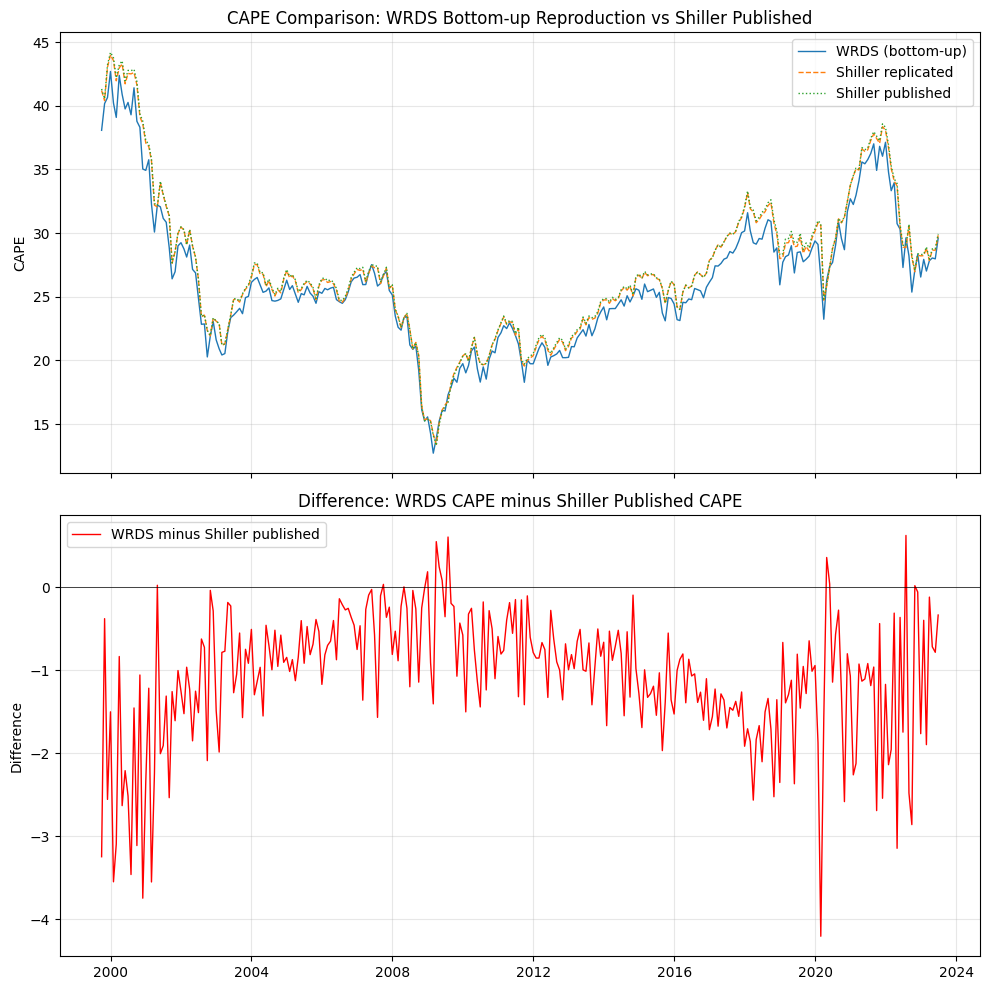

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax1.plot(comparison.index, comparison['CAPE_wrds'],
         label='WRDS (bottom-up)',
         linewidth=1)
ax1.plot(comparison.index, comparison['CAPE_shiller_replicated'],
         label='Shiller replicated',
         linewidth=1,
         linestyle='--')
ax1.plot(comparison.index, comparison['cape_shiller'],
         label='Shiller published',
         linewidth=1,
         linestyle=':')
ax1.set_title('CAPE Comparison: WRDS Bottom-up Reproduction vs Shiller Published')
ax1.set_ylabel('CAPE')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(comparison.index, comparison['diff_vs_published'],
         label='WRDS minus Shiller published',
         color='red',
         linewidth=1)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Difference: WRDS CAPE minus Shiller Published CAPE')
ax2.set_ylabel('Difference')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cape_comparison.png', dpi=150)
plt.show()

Anything tighter than that would require S&P's proprietary index earnings tape

In [ ]:
# Final honest accounting of residual sources
residual_sources = {
    'ibq vs S&P as-reported definition': {
        'magnitude': '0.5-1.5 pts',
        'explanation': """S&P makes specific adjustments to constituent earnings
        (e.g. excluding certain pension costs, using specific treatment for
        financial subsidiaries) that aren't replicable from ibq alone""",
        'periods_affected': 'All periods, systematic'
    },
    'Compustat reporting lag': {
        'magnitude': '0.3-1.0 pts',
        'explanation': """Most recent 1-2 months have incomplete filings.
        ffill carries stale earnings forward while price moves,
        distorting the yield temporarily""",
        'periods_affected': 'Every month-end, washes out over 120mo avg'
    },
    'Index divisor adjustments': {
        'magnitude': '0.5-2.0 pts at extremes',
        'explanation': """S&P adjusts the index divisor for corporate actions
        (spin-offs, buybacks, additions/deletions). Your mktcap-weighted
        yield doesn't perfectly replicate this divisor arithmetic""",
        'periods_affected': '1999-2001 dot-com, 2020 COVID most visible'
    },
    'Restatements': {
        'magnitude': '1-4 pts in crisis periods',
        'explanation': """Compustat ibq reflects RESTATED earnings.
        Shiller's series was frozen at originally reported values.
        Post-crisis write-downs (2001, 2009, 2020) hit Compustat
        retroactively but never appeared in Shiller's published series""",
        'periods_affected': '2000-2002, 2008-2010, 2020 worst'
    }
}

for source, detail in residual_sources.items():
    print(f"\n{source}")
    print(f"  Magnitude:{detail['magnitude']}")
    print(f"  Periods:{detail['periods_affected']}")
    print(f"  Explanation:{detail['explanation']}")


ibq vs S&P as-reported definition
  Magnitude:0.5-1.5 pts
  Periods:All periods, systematic
  Explanation:S&P makes specific adjustments to constituent earnings 
        (e.g. excluding certain pension costs, using specific treatment for 
        financial subsidiaries) that aren't replicable from ibq alone

Compustat reporting lag
  Magnitude:0.3-1.0 pts
  Periods:Every month-end, washes out over 120mo avg
  Explanation:Most recent 1-2 months have incomplete filings.
        ffill carries stale earnings forward while price moves,
        distorting the yield temporarily

Index divisor adjustments
  Magnitude:0.5-2.0 pts at extremes
  Periods:1999-2001 dot-com, 2020 COVID most visible
  Explanation:S&P adjusts the index divisor for corporate actions
        (spin-offs, buybacks, additions/deletions). Your mktcap-weighted
        yield doesn't perfectly replicate this divisor arithmetic

Restatements
  Magnitude:1-4 pts in crisis periods
  Periods:2000-2002, 2008-2010, 2020 worst
  Exp